# Sub-daily ET Dynamics Across COSMOS-UK Sites

**Objective**: characterise the shape, timing, and drivers of the within-day evapotranspiration cycle across the COSMOS-UK network, and how that cycle varies by season and land cover.

Notebooks 01–03 worked at **daily** resolution (drydown timescales, seasonal totals). This notebook works at the native **30-minute** resolution to ask a different question: not *how much* ET occurs, but *when* and *how* it unfolds over the course of a day — and whether that pattern differs systematically across sites.

## Plan

### Background

ET is driven by the diurnal cycle of available energy and atmospheric demand, but vegetation and soil moisture can modulate that response — delaying, damping, or reshaping it. Two signatures are diagnostic:

- **Phase lag**: does ET peak in step with potential ET (`PE`, an energy/demand proxy), or lag/lead it? A lag suggests thermal or hydraulic inertia (e.g. canopy water storage, stomatal opening delay); a lead is less physically expected and would flag data/processing artefacts.
- **Hysteresis**: plotting ET against a driver (`PE` or `VPD`) over a full day traces a loop rather than a single curve, because morning and afternoon conditions at the same driver value differ (e.g. rising vs falling VPD, wetter vs drier canopy). Loop area and direction indicate the strength and sense of this decoupling — e.g. progressive stomatal closure through the afternoon (VPD-limitation) produces a characteristic clockwise loop.

> **⚠️ Data caveat — no net radiation in this dataset.** COSMOS-UK fastflux L1/L2 do not include a net radiation (`Rn`) variable. Every "energy/demand driver" reference below uses **potential evapotranspiration (`PE`)** as a proxy instead — its Penman–Monteith diurnal course tracks available energy reasonably well under well-watered conditions, but it is not a direct radiation measurement and will itself respond to VPD/wind, not just Rn. Section "Load data" below defines a single `ENERGY_VAR`/`ENERGY_LABEL` pair used throughout the notebook — swap it there to use real `Rn` (e.g. from a gridded product) instead; see that cell for how.

Available sub-daily drivers in the L1 data: `PE` (potential ET, energy/demand proxy), `VPD`, `TS` (air temperature), `TDEW`, `WS_MAX`, `BOWEN_RATIO`.

### Sections

1. **Load data** — L1 (`PE`, `VPD`, `TS`, `BOWEN_RATIO`) + L2 (QC'd `ET`) at 30-min resolution for all 45 sites; merge on `DATE_TIME`/`SITE_ID`; join site metadata (land cover, lat/lon) for grouping. Filter `-9999`.
2. **Data availability check** — confirm sub-daily record completeness per site before building composites (a diurnal average is only meaningful with enough time-of-day coverage).
3. **Mean diurnal composite per site** — average `ET`, `PE`/`Rn`, `VPD` by time-of-day (30-min bins) across the record, separately by season (DJF/MAM/JJA/SON), to get a representative daily curve per site per season.
4. **Diurnal shape metrics** — for each site/season composite, extract: peak ET magnitude, time of peak, curve width (FWHM), and morning-rise vs afternoon-decline asymmetry.
5. **Phase relationship: ET vs energy driver** — cross-correlate the two composite curves per site/season to find the lag (in 30-min steps) that maximises correlation. Compare lag distribution across sites and seasons.
6. **Hysteresis: ET vs VPD** — plot ET against VPD through the diurnal cycle and quantify loop area/direction (shoelace formula on the closed diurnal path) as an index of within-day decoupling.
7. **Seasonal variation within sites** — compare each site's summer vs winter diurnal shape metrics (peak timing, asymmetry, hysteresis index).
8. **Cross-site comparison by land cover** — group the shape/lag/hysteresis metrics by land cover class and compare distributions.
9. **Network summary table** — one row per site×season with the key metrics, as the quantitative summary of the analysis.
10. **Conclusions** — synthesise which sites/land covers show the most–least coupled (in-phase, low-hysteresis) sub-daily ET behaviour.

## 0. Setup

In [1]:
import importlib, subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

DATA_DIR = 'data'

### Energy / atmospheric-demand driver — swap point

This is the single place that decides which variable stands in for available energy throughout the notebook. See the data caveat in the Plan above.

In [3]:
# ── Energy / atmospheric-demand driver configuration ─────────────────────────
# This dataset has no net radiation (Rn) variable, so potential evapotranspiration
# (PE, Penman-Monteith) is used as the energy/demand proxy throughout this notebook.
#
# To use net radiation instead (e.g. from a gridded product such as CHESS-met or
# ERA5-Land): load your own Rn series indexed by DATE_TIME/SITE_ID, merge it into
# the half-hourly frame returned by `load_site()` below under a new column (e.g.
# 'RN'), and point ENERGY_VAR/ENERGY_LABEL at it here. Every downstream section
# reads only ENERGY_VAR/ENERGY_LABEL, so no other code needs to change.
ENERGY_VAR   = 'PE'                                # <- swap to 'RN' (or your own column) for real net radiation
ENERGY_LABEL = 'PE (potential ET, mm / 30 min)'    # <- update to match, e.g. 'Rn (W m⁻²)'

## 1. Load data

Site metadata first (land cover, coordinates), then half-hourly L1+L2 data for every site, merged into one long frame.

In [4]:
meta = pd.read_csv(f'{DATA_DIR}/cosmos-uk_sitemetadata_2014-2024.csv',
                   parse_dates=['START_DATE', 'END_DATE',
                                'DATE_INSTALLED', 'DATE_DECOMMISSIONED'],
                   dayfirst=True)
site_ids = sorted(meta['SITE_ID'].unique())
print(f"{len(site_ids)} sites in metadata")

45 sites in metadata


/tmp/ipykernel_1420144/1648573801.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  meta = pd.read_csv(f'{DATA_DIR}/cosmos-uk_sitemetadata_2014-2024.csv',


In [5]:
def load_site(site_id, data_dir=DATA_DIR):
    """
    Load L1 (PE, VPD, TS, BOWEN_RATIO) and L2 (QC'd ET), merge at 30-min res.
    To add a net-radiation column instead of PE, read it here (or merge in a
    separate gridded-data frame) and include it alongside the other L1 columns.
    Returns a half-hourly DataFrame indexed by DATE_TIME.
    """
    sid = site_id.lower()
    l1_path = glob.glob(f'{data_dir}/cosmos-uk_{sid}_fastflux_l1_*.csv')[0]
    l2_path = glob.glob(f'{data_dir}/cosmos-uk_{sid}_fastflux_l2_*.csv')[0]

    l1 = pd.read_csv(l1_path, na_values=-9999, parse_dates=['DATE_TIME'],
                     usecols=['DATE_TIME', 'PE', 'VPD', 'TS', 'BOWEN_RATIO'])
    l2 = pd.read_csv(l2_path, na_values=-9999, parse_dates=['DATE_TIME'],
                     usecols=['DATE_TIME', 'ET'])

    l1['DATE_TIME'] = pd.to_datetime(l1['DATE_TIME'], utc=True)
    l2['DATE_TIME'] = pd.to_datetime(l2['DATE_TIME'], utc=True)

    hh = l2.merge(l1, on='DATE_TIME').set_index('DATE_TIME').sort_index()
    hh['SITE_ID'] = site_id
    return hh


def load_all_sites(site_ids, data_dir=DATA_DIR):
    return pd.concat([load_site(sid, data_dir) for sid in site_ids]).reset_index()


all_hh = load_all_sites(site_ids)
all_hh['HOUR']  = all_hh['DATE_TIME'].dt.hour + all_hh['DATE_TIME'].dt.minute / 60
all_hh['MONTH'] = all_hh['DATE_TIME'].dt.month

print(f"{all_hh['SITE_ID'].nunique()} sites loaded, {len(all_hh):,} half-hourly rows")
all_hh.head(3)

45 sites loaded, 6,189,116 half-hourly rows


,DATE_TIME,ET,VPD,BOWEN_RATIO,TS,PE,SITE_ID,HOUR,MONTH
0,2015-06-10 16:30:00+00:00,0.08428,1344.3,0.38750,295.3,0.16943,BALRD,16.5,6
1,2015-06-10 17:00:00+00:00,0.07325,1306.4,0.33446,295.4,0.14713,BALRD,17.0,6
2,2015-06-10 17:30:00+00:00,0.05831,1306.5,0.34655,295.3,0.12653,BALRD,17.5,6


## 2. Data availability check

A mean diurnal composite is only meaningful with enough time-of-day coverage — check valid `ET` records per site and set a minimum-completeness threshold for the cross-site sections.

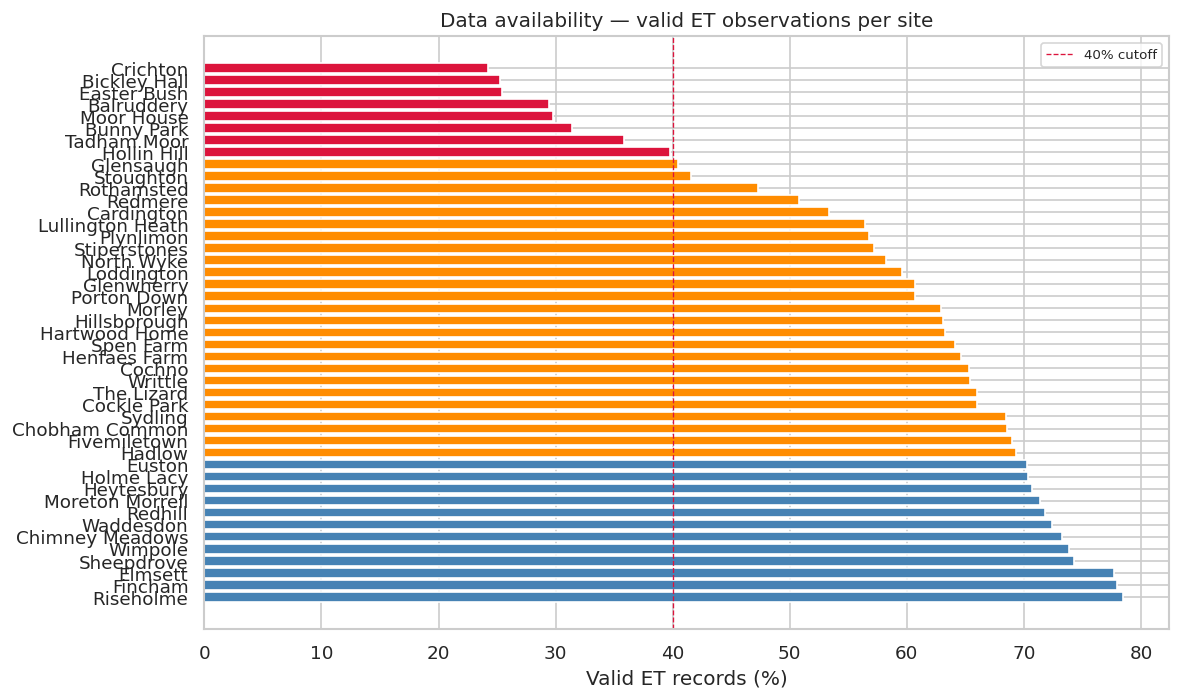

37/45 sites retained for cross-site analysis (≥40% valid)


In [6]:
avail = (all_hh.groupby('SITE_ID')
         .agg(n_valid=('ET', 'count'), n_total=('DATE_TIME', 'count'))
         .assign(pct_valid=lambda d: 100 * d['n_valid'] / d['n_total'])
         .merge(meta[['SITE_ID', 'SITE_NAME', 'LAND_COVER']], on='SITE_ID')
         .sort_values('pct_valid', ascending=False)
         .reset_index(drop=True))

MIN_PCT_VALID = 40  # sites below this are excluded from cross-site sections (7-9)
usable_sites = avail.loc[avail['pct_valid'] >= MIN_PCT_VALID, 'SITE_ID'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
colors = avail['pct_valid'].apply(
    lambda v: 'steelblue' if v >= 70 else 'darkorange' if v >= MIN_PCT_VALID else 'crimson')
ax.barh(avail['SITE_NAME'], avail['pct_valid'], color=colors)
ax.axvline(MIN_PCT_VALID, color='crimson', linestyle='--', linewidth=0.8,
           label=f'{MIN_PCT_VALID}% cutoff')
ax.set_xlabel('Valid ET records (%)')
ax.set_title('Data availability — valid ET observations per site')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"{len(usable_sites)}/{len(avail)} sites retained for cross-site analysis (≥{MIN_PCT_VALID}% valid)")

## 3. Mean diurnal composite per site

Average `ET`, the energy driver, and `VPD` by half-hour-of-day, per site and season. This composite curve is the input to every shape/lag/hysteresis metric below.

In [7]:
def month_to_season(m):
    if m in (12, 1, 2): return 'Winter'
    if m in (3, 4, 5):  return 'Spring'
    if m in (6, 7, 8):  return 'Summer'
    return 'Autumn'

all_hh['SEASON'] = all_hh['MONTH'].map(month_to_season)

def diurnal_composite(df, value_vars=('ET', ENERGY_VAR, 'VPD')):
    """Mean diurnal cycle (by half-hour-of-day) per SITE_ID x SEASON."""
    return (df.dropna(subset=list(value_vars))
              .groupby(['SITE_ID', 'SEASON', 'HOUR'])[list(value_vars)]
              .mean()
              .reset_index())

composite = diurnal_composite(all_hh)
print(f"{len(composite):,} site×season×half-hour composite rows")

8,124 site×season×half-hour composite rows


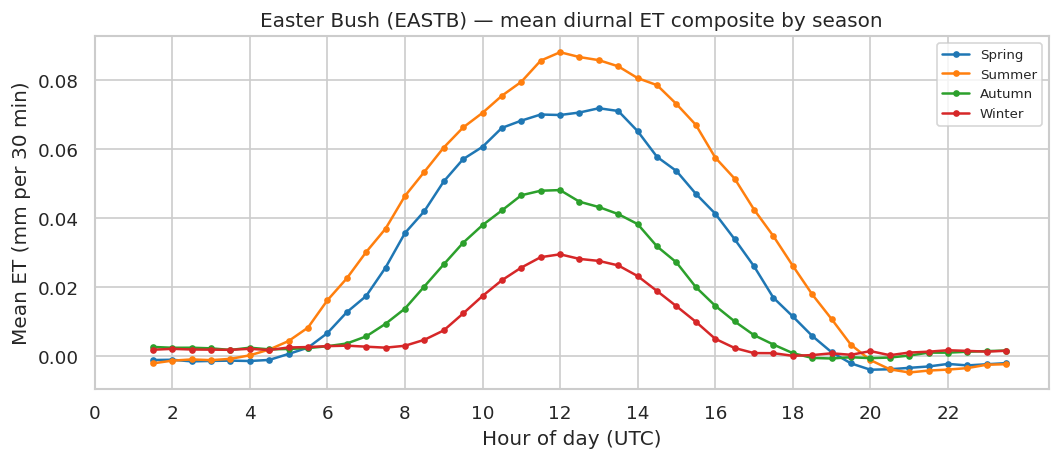

In [8]:
SITE = 'EASTB'  # change to any SITE_ID
site_name = meta.loc[meta['SITE_ID'] == SITE, 'SITE_NAME'].values[0]
site_composite = composite[composite['SITE_ID'] == SITE]

fig, ax = plt.subplots(figsize=(9, 4))
for season in ['Spring', 'Summer', 'Autumn', 'Winter']:
    grp = site_composite[site_composite['SEASON'] == season]
    ax.plot(grp['HOUR'], grp['ET'], marker='o', markersize=3, label=season)

ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Mean ET (mm per 30 min)')
ax.set_title(f'{site_name} ({SITE}) — mean diurnal ET composite by season')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Diurnal shape metrics

For each site/season composite curve, extract: peak timing/magnitude, curve width (FWHM), and rise/decline asymmetry.

In [9]:
def diurnal_shape_metrics(curve, value_col='ET'):
    """
    Shape metrics for one site/season mean-diurnal curve:
    peak_hour, peak_value, fwhm_hours (duration above half-max), and
    asymmetry (decline duration / rise duration around the peak — >1 means
    the afternoon decline is slower/longer than the morning rise).
    """
    curve = curve.sort_values('HOUR')
    hours = curve['HOUR'].to_numpy()
    values = curve[value_col].to_numpy()

    peak_idx = int(np.argmax(values))
    peak_hour = hours[peak_idx]
    peak_value = values[peak_idx]

    half_max = peak_value / 2
    above = values >= half_max
    step = hours[1] - hours[0]
    fwhm_hours = above.sum() * step if above.any() else np.nan

    above_idx = np.where(above)[0]
    rise_hours = (peak_idx - above_idx.min()) * step if above.any() else np.nan
    fall_hours = (above_idx.max() - peak_idx) * step if above.any() else np.nan
    asymmetry = fall_hours / rise_hours if rise_hours else np.nan

    return pd.Series({'peak_hour': peak_hour, 'peak_value': peak_value,
                       'fwhm_hours': fwhm_hours, 'asymmetry': asymmetry})

shape_metrics = (composite.groupby(['SITE_ID', 'SEASON'])
                 .apply(lambda g: diurnal_shape_metrics(g, value_col='ET'), include_groups=False)
                 .reset_index())
shape_metrics.head()

,SITE_ID,SEASON,peak_hour,peak_value,fwhm_hours,asymmetry
0,BALRD,Autumn,11.5,0.039237,6.5,1.400
1,BALRD,Spring,12.0,0.061995,8.0,0.875
2,BALRD,Summer,12.5,0.080901,10.0,0.900
3,BALRD,Winter,12.0,0.028552,5.0,1.250
4,BICKL,Autumn,12.0,0.054963,7.5,1.000


## 5. Phase relationship: ET vs energy driver (PE by default)

Cross-correlate the ET and energy-driver composite curves at half-hour lags to find the offset that maximises correlation — a positive lag means ET peaks after the energy driver. Uses whatever `ENERGY_VAR` points at (see Section 0).

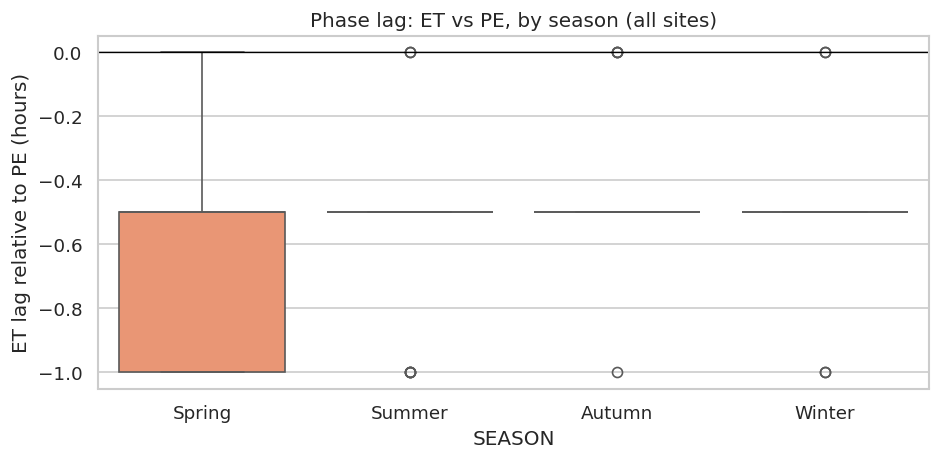

In [10]:
def best_lag(curve, ref_col=ENERGY_VAR, target_col='ET', max_lag=12):
    """
    Circular cross-correlation of `target_col` against `ref_col` over lags of
    -max_lag..+max_lag half-hour steps. Positive lag = target peaks after ref.
    Returns the best-fit lag in hours.
    """
    curve = curve.sort_values('HOUR')
    ref = curve[ref_col].to_numpy()
    tgt = curve[target_col].to_numpy()
    lags = range(-max_lag, max_lag + 1)
    corrs = [np.corrcoef(tgt, np.roll(ref, lag))[0, 1] for lag in lags]
    best = lags[int(np.argmax(corrs))]
    return best * 0.5  # half-hour steps -> hours

lag_results = (composite.groupby(['SITE_ID', 'SEASON'])
               .apply(lambda g: best_lag(g), include_groups=False)
               .reset_index(name='et_lag_hours'))

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=lag_results, x='SEASON', y='et_lag_hours',
            order=['Spring', 'Summer', 'Autumn', 'Winter'], hue='SEASON',
            legend=False, palette='Set2', ax=ax)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_ylabel(f'ET lag relative to {ENERGY_VAR} (hours)')
ax.set_title(f'Phase lag: ET vs {ENERGY_VAR}, by season (all sites)')
plt.tight_layout()
plt.show()

## 6. Hysteresis: ET vs VPD

A day's (VPD, ET) path traces a loop rather than a single curve, because morning and afternoon conditions differ at the same VPD. Loop area (shoelace formula on the closed diurnal path, normalised by the VPD range) summarises the strength of this decoupling; sign indicates direction.

In [11]:
def hysteresis_index(curve, x_col='VPD', y_col='ET'):
    """
    Signed, range-normalised loop area traced by (x_col, y_col) over one mean
    diurnal cycle (shoelace formula on the closed 24h path). Positive = clockwise
    loop (afternoon branch below the morning branch at matched x) — e.g. the
    signature of progressive stomatal closure through the day.
    """
    curve = curve.sort_values('HOUR')
    x = curve[x_col].to_numpy()
    y = curve[y_col].to_numpy()
    x = np.append(x, x[0])
    y = np.append(y, y[0])
    area = 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])
    x_range = curve[x_col].max() - curve[x_col].min()
    return area / x_range if x_range > 0 else np.nan

hyst_results = (composite.groupby(['SITE_ID', 'SEASON'])
                .apply(lambda g: hysteresis_index(g), include_groups=False)
                .reset_index(name='hysteresis_index'))

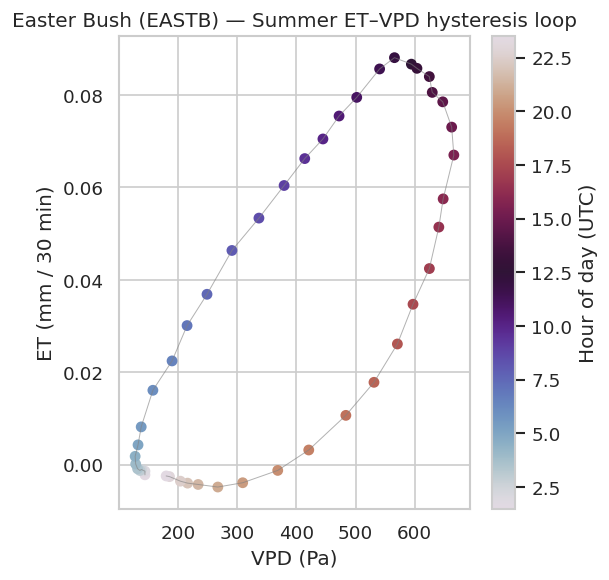

In [12]:
example = (composite[(composite['SITE_ID'] == SITE) & (composite['SEASON'] == 'Summer')]
           .sort_values('HOUR'))

fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(example['VPD'], example['ET'], c=example['HOUR'], cmap='twilight', s=30)
ax.plot(example['VPD'], example['ET'], color='grey', linewidth=0.6, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Hour of day (UTC)')
ax.set_xlabel('VPD (Pa)')
ax.set_ylabel('ET (mm / 30 min)')
ax.set_title(f'{site_name} ({SITE}) — Summer ET–VPD hysteresis loop')
plt.tight_layout()
plt.show()

## 7. Seasonal variation within sites

Compare each site's Summer vs Winter shape metrics: does peak timing shift, and does the rise/decline asymmetry change with day length and canopy state?

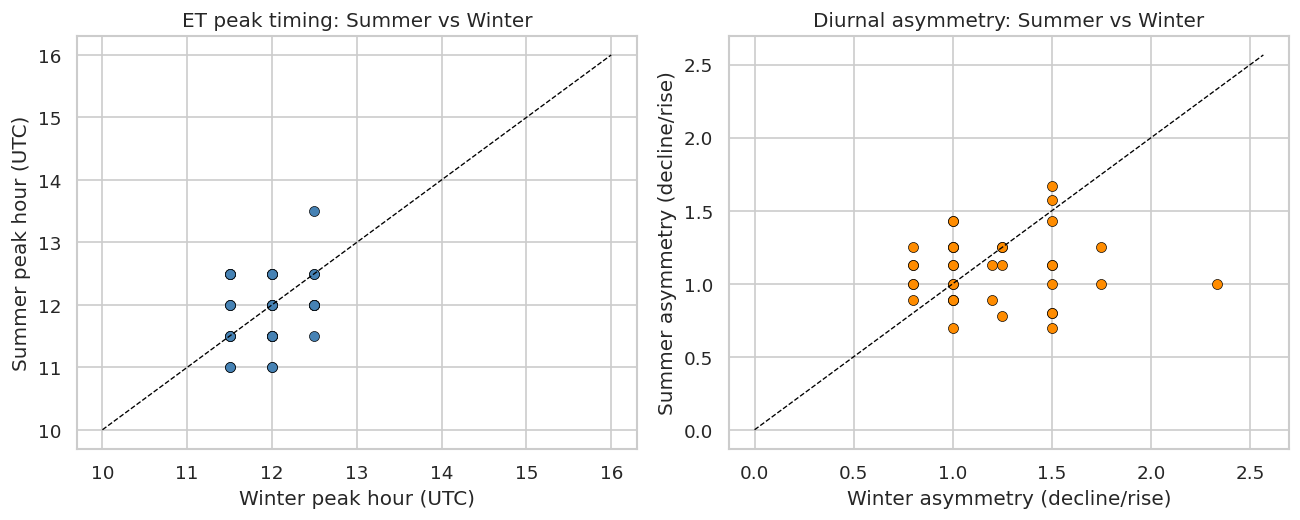

In [13]:
seasonal_wide = (shape_metrics[shape_metrics['SEASON'].isin(['Summer', 'Winter'])]
                 .pivot(index='SITE_ID', columns='SEASON', values=['peak_hour', 'asymmetry'])
                 .dropna())
seasonal_wide.columns = ['_'.join(c) for c in seasonal_wide.columns]
seasonal_wide = seasonal_wide[seasonal_wide.index.isin(usable_sites)].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(seasonal_wide['peak_hour_Winter'], seasonal_wide['peak_hour_Summer'],
                color='steelblue', edgecolors='k', linewidths=0.4)
lims = [10, 16]
axes[0].plot(lims, lims, 'k--', linewidth=0.8)
axes[0].set_xlabel('Winter peak hour (UTC)')
axes[0].set_ylabel('Summer peak hour (UTC)')
axes[0].set_title('ET peak timing: Summer vs Winter')

axes[1].scatter(seasonal_wide['asymmetry_Winter'], seasonal_wide['asymmetry_Summer'],
                color='darkorange', edgecolors='k', linewidths=0.4)
lims2 = [0, seasonal_wide[['asymmetry_Winter', 'asymmetry_Summer']].to_numpy().max() * 1.1]
axes[1].plot(lims2, lims2, 'k--', linewidth=0.8)
axes[1].set_xlabel('Winter asymmetry (decline/rise)')
axes[1].set_ylabel('Summer asymmetry (decline/rise)')
axes[1].set_title('Diurnal asymmetry: Summer vs Winter')

plt.tight_layout()
plt.show()

## 8. Cross-site comparison by land cover

Join the shape, lag, and hysteresis metrics with site metadata and compare distributions across land-cover classes (restricted to sites meeting the data-availability threshold from Section 2).

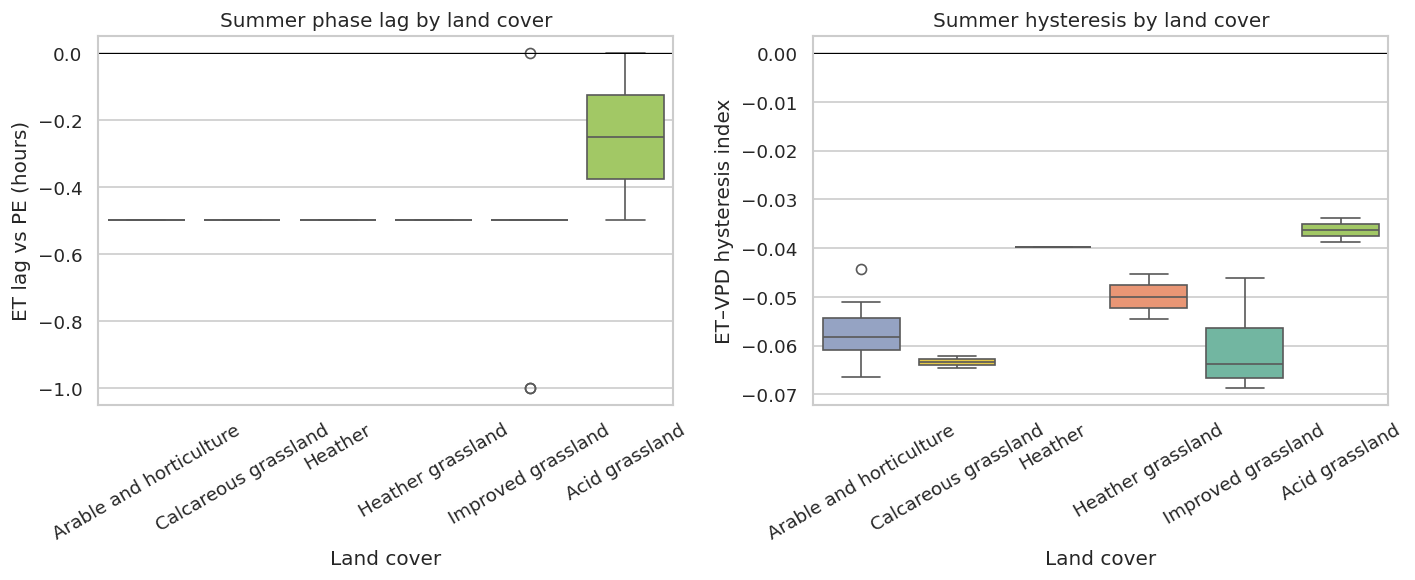

In [14]:
metrics = (shape_metrics
           .merge(lag_results, on=['SITE_ID', 'SEASON'])
           .merge(hyst_results, on=['SITE_ID', 'SEASON'])
           .merge(meta[['SITE_ID', 'LAND_COVER']], on='SITE_ID'))
metrics = metrics[metrics['SITE_ID'].isin(usable_sites)].copy()
metrics['LC_short'] = (metrics['LAND_COVER']
                       .str.replace(r' \(.*\)', '', regex=True)
                       .str.strip())

summer = metrics[metrics['SEASON'] == 'Summer']
lc_order = (summer.groupby('LC_short')['et_lag_hours'].median()
            .sort_values().index)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=summer, x='LC_short', y='et_lag_hours', order=lc_order,
            hue='LC_short', legend=False, palette='Set2', ax=axes[0])
axes[0].axhline(0, color='k', linewidth=0.6)
axes[0].set_xlabel('Land cover')
axes[0].set_ylabel(f'ET lag vs {ENERGY_VAR} (hours)')
axes[0].set_title('Summer phase lag by land cover')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=summer, x='LC_short', y='hysteresis_index', order=lc_order,
            hue='LC_short', legend=False, palette='Set2', ax=axes[1])
axes[1].axhline(0, color='k', linewidth=0.6)
axes[1].set_xlabel('Land cover')
axes[1].set_ylabel('ET–VPD hysteresis index')
axes[1].set_title('Summer hysteresis by land cover')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 9. Network summary table

One row per site (Summer values), the key quantitative outputs of the analysis, grouped by land cover.

In [15]:
summary_cols = ['SITE_ID', 'LC_short', 'peak_hour', 'fwhm_hours', 'asymmetry',
                'et_lag_hours', 'hysteresis_index']
network_summary = (summer[summary_cols]
                   .merge(meta[['SITE_ID', 'SITE_NAME']], on='SITE_ID')
                   .sort_values(['LC_short', 'SITE_ID'])
                   .set_index('SITE_ID'))
network_summary

,LC_short,peak_hour,fwhm_hours,asymmetry,et_lag_hours,hysteresis_index,SITE_NAME
SITE_ID,,,,,,,
HENFS,Acid grassland,12.0,9.0,1.428571,0.0,-0.033932,Henfaes Farm
PLYNL,Acid grassland,12.0,9.5,1.250000,-0.5,-0.038731,Plynlimon
COCLP,Arable and horticulture,11.5,9.5,1.250000,-0.5,-0.044367,Cockle Park
ELMST,Arable and horticulture,11.0,9.0,1.428571,-0.5,-0.060836,Elmsett
FINCH,Arable and horticulture,12.5,9.5,0.800000,-0.5,-0.054634,Fincham
HLACY,Arable and horticulture,12.0,9.5,1.000000,-0.5,-0.056889,Holme Lacy
LODTN,Arable and horticulture,11.5,9.0,1.125000,-0.5,-0.066476,Loddington
MORLY,Arable and horticulture,11.5,9.0,1.125000,-0.5,-0.051050,Morley
NWYKE,Arable and horticulture,12.0,8.5,1.000000,-0.5,-0.063608,North Wyke


In [16]:
lc_summary = (summer.groupby('LC_short')[['peak_hour', 'fwhm_hours', 'asymmetry',
                                          'et_lag_hours', 'hysteresis_index']]
              .agg(['mean', 'std'])
              .round(2))
lc_summary

peak_hour       fwhm_hours       asymmetry        \
                             mean   std       mean   std      mean   std   
LC_short                                                                   
Acid grassland              12.00  0.00       9.25  0.35      1.34  0.13   
Arable and horticulture     11.65  0.47      12.00  6.69      1.17  0.24   
Calcareous grassland        11.75  0.35       9.00  0.71      1.00  0.00   
Heather                     12.00   NaN       9.50   NaN      1.00   NaN   
Heather grassland           12.00  0.00       9.00  0.00      1.12  0.00   
Improved grassland          12.18  0.61      12.32  7.27      1.02  0.24   

                        et_lag_hours       hysteresis_index        
                                mean   std             mean   std  
LC_short                                                           
Acid grassland                 -0.25  0.35            -0.04  0.00  
Arable and horticulture        -0.50  0.00            -0.06  0.01  
Calcareous grassland           -0.50  0.00            -0.06  0.00  
Heather                        -0.50   NaN            -0.04   NaN  
Heather grassland              -0.50  0.00            -0.05  0.01  
Improved grassland             -0.53  0.21            -0.06  0.01

## 10. Conclusions

*(Fill in after inspecting the outputs above — this section is a template for the write-up.)*

| Metric | Description | Key finding |
|--------|-------------|-------------|
| Peak hour | Time of day of maximum mean ET | — |
| FWHM | Duration the diurnal ET curve stays above half its peak | — |
| Asymmetry | Ratio of afternoon-decline to morning-rise duration | — |
| ET lag vs energy driver | Hours ET peak trails the energy/demand proxy | — |
| Hysteresis index | Signed loop area between ET and VPD over a day | — |

Sites/land covers with the largest lag and hysteresis index show the strongest sub-daily decoupling between ET and atmospheric demand — consistent with stronger canopy/soil-moisture control on water loss. Re-run Section "Energy / atmospheric-demand driver" with real `Rn` data to check how much of the lag/hysteresis signal is an artefact of using `PE` as the energy proxy rather than a genuine physiological signal.